In this notebook we care to minimize the cost funtion

\begin{equation}
    J(u) = \|Ru - y\|_2^2 + \alpha \left\|\sqrt{(D_xu)^2 + (D_yu)^2}\right\|_1,
\end{equation}

We rewrite it using the weight matrix 

\begin{equation}
    W = \text{diag}\left[((D_xu)^2 + (D_yu)^2)^{-1/2}\right].
\end{equation}

Such that we can write the cost function as 

\begin{equation*}
    J(u) = \|Ru - y\|_2^2 + \alpha \left\|\begin{bmatrix}
                                            W^{1/2}\\
                                            & W^{1/2}\\
                                        \end{bmatrix}Du \right\|_2^2 = \left\| \begin{bmatrix}
        R\\
        \sqrt{\alpha} \tilde{W}^{1/2}D
    \end{bmatrix} u - \begin{bmatrix}
        y\\
        0 
    \end{bmatrix} \right \|_2^2,
\end{equation*}

We try to solve this least squares problem using the BlockFramework from CIL with the CGLS function

In [1]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared
from cil.optimisation.utilities import callbacks

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator, MaskOperator

In [2]:
# setting pixels and angles
n_pixels = 265
n_angles = 50

## Setting up CT problem

In [3]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [4]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

# Setup acquisition geometry
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


## IRN for TV regularisation with CGLS function

In [7]:
def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom


def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

In [8]:
def tv_cgls(initial, inner_iter, outer_iter, R, sino, alpha, er, cg_tol, exact):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - y||_2^2 + alpha TV(u)

    by minimising 

    J(u) = ||Ru - y||_2^2 + alpha ||tilde{W}_k Du||_2^2

    via the BlockFramework and the cgls function from CIL. The matrix W_k is reweighted in each iteration, and, 

    tilde{W}_k = [[W_k, 0], 
                  [0, W_k]]

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        R:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'y' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)
        cg_tol:     tolerance for cg (float)
        exact:      if known, the exact solution to the reconstruction problem (ImageData), 
                    if not known, put None and the backward error is computed

    Output
        uk:         reconstructed image (ImageData)
        err:        backward error or forward error depending on what is inputted in 'exact' (numpy array)
    
    """

    uk = initial.copy()

    # functions that don't depend on iteration for reweighting regularisation term
    get_ig = R.domain_geometry()
    gradient_operator = GradientOperator(get_ig)   # function that computes D_x, D_y

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    if exact == None:
        err_temp = norm(R.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):
        
        # creating the weights matrix W^{1/2}
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/4))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        W_diagonal = DiagonalOperator(uk_reweighted)

        # creating zero operator blocks
        zero_operator = ZeroOperator(get_ig)

        # reg_operator = [W^{1/2}D_x W^{1/2}D_y]^T
        w_matrix = BlockOperator(W_diagonal, zero_operator, W_diagonal, zero_operator, shape=(2,2))
        reg_operator = CompositionOperator(w_matrix, gradient_operator)

        # create block operator
        operator_block = BlockOperator(R, np.sqrt(alpha)*reg_operator)

        # create block data container
        zero_block = reg_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.CGLSEarlyStopping(cg_tol)])

        uk = cgls.solution

        Ruk_min_sino = R.direct(uk) - sino

        if exact == None:
            err_temp = norm(Ruk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Ruk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err


## Results

In [16]:
import time
R, sino, ig, ag, phantom = get_A(n_angles=50, n_pixels=265)
sino_noise = add_poss_noise(background_counts=20000, n_angles=50, n_pixels=265)

tstart = time.time()
sol, sol_error = tv_cgls(initial=ig.allocate(0),
                              inner_iter=100,
                              outer_iter=5,
                              R=R,
                              sino=sino_noise,
                              alpha= 7e-7,
                              er=None,
                              cg_tol= 2e-2,
                              exact=phantom)
tend = time.time()

print("time for computation", tend-tstart)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


The norm of the residual is less than 0.02 times the norm of the initial residual and so the algorithm is terminated
time for computation 28.968276977539062


<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
C:\Users\femke\AppData\Local\Temp\ipykernel_12160\2596571278.py:10: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|u_{exact} - u\|_2^2$')


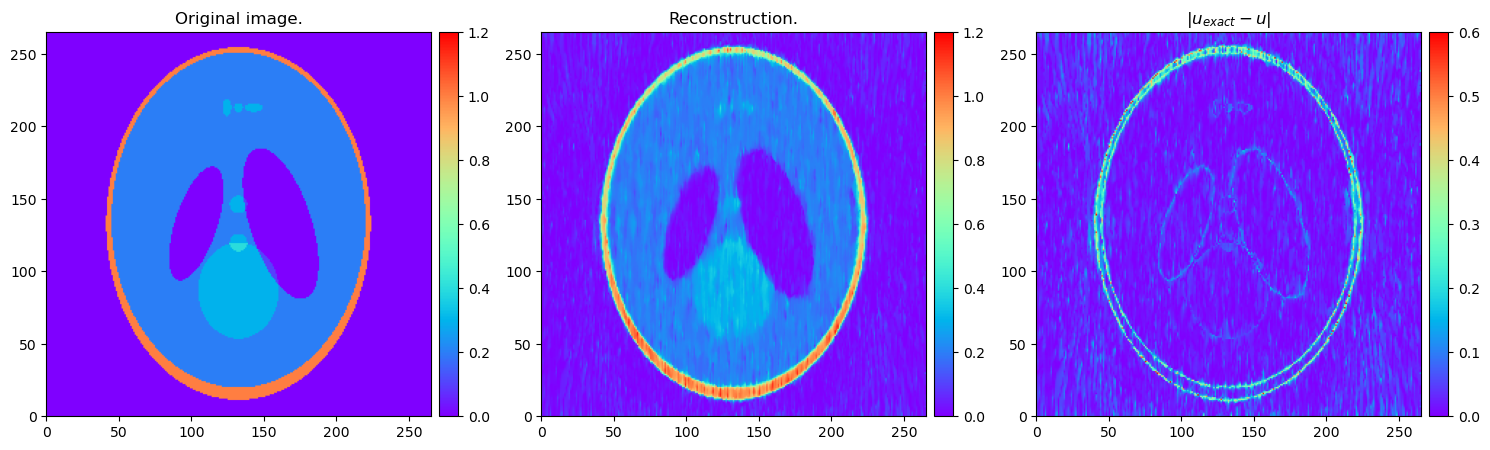

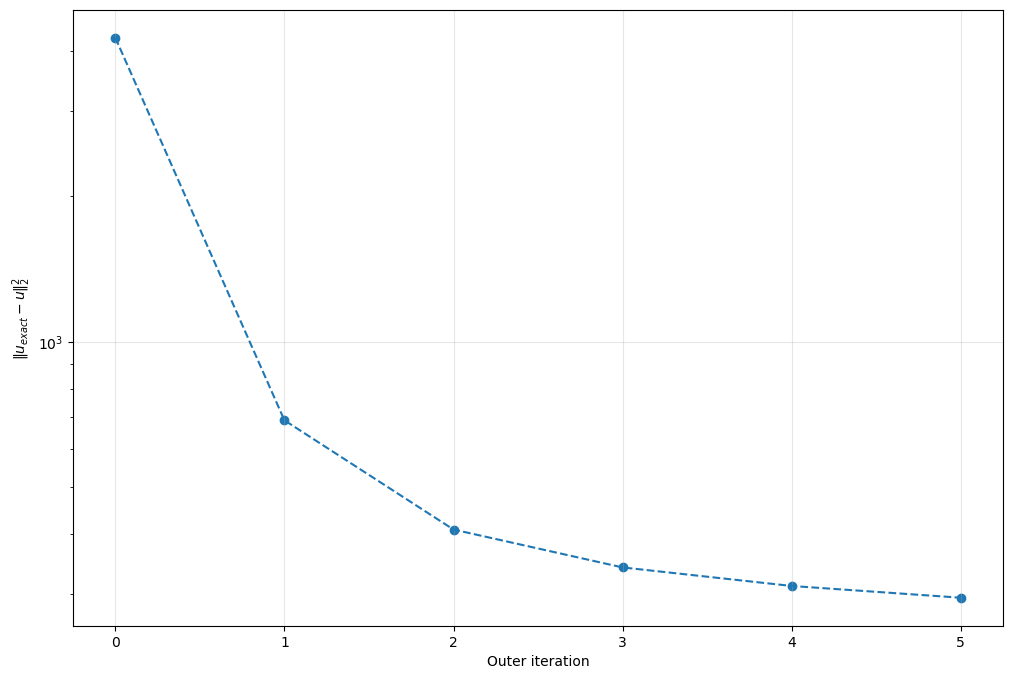

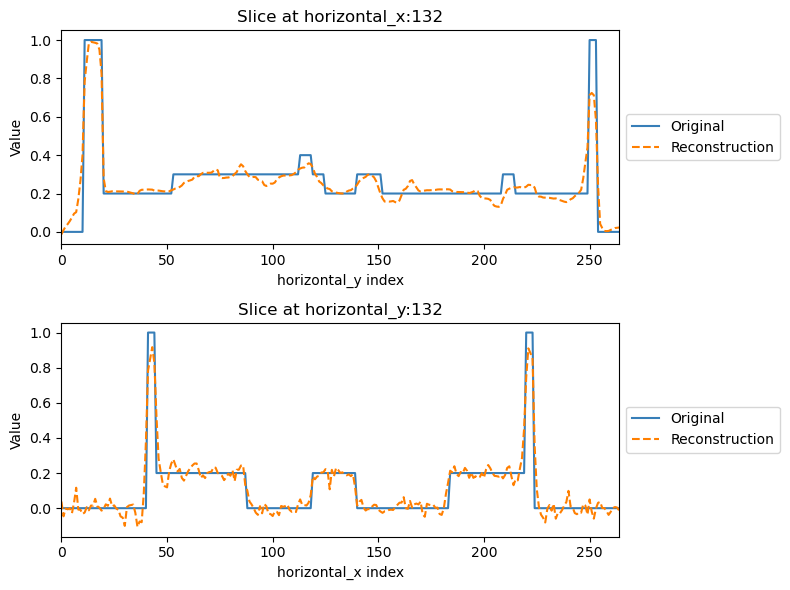

In [17]:
show2D([phantom, sol.abs(), (phantom-sol).abs()], ['Original image.', 'Reconstruction.', '$|u_{exact} - u|$'], 
       num_cols=3,
       cmap='rainbow', 
       axis_labels=('', ''), 
       fix_range= [(0,1.2), (0,1.2),(0,0.6)])
x = np.linspace(0,len(sol_error) - 1, len(sol_error))

plt.figure(figsize=(12,8))
plt.semilogy(x, sol_error, linestyle='--')
plt.ylabel('$\|u_{exact} - u\|_2^2$')
plt.xlabel('Outer iteration')
plt.scatter(x,sol_error)
plt.grid(alpha=0.3)

show1D([phantom, sol], dataset_labels=['Original', 'Reconstruction'])